In [1]:
import numpy as np
from pathlib import Path
from tqdm import trange
import matplotlib.pyplot as plt
from natsort import natsorted
import dask.array as da
import dask_image.imread
import cv2
import nibabel as nib
from ultralytics import YOLO

In [2]:
in_dir = '/Users/rubyngo/bigpurple_data/micmac'
# CONSIDER TRYING TO DO GLOBAL THRESHOLDING AGAIN, BUT TAKING IMAGE CENTER AND THEN SOME SQUARE FROM THERE TO CALCULATE GLOBAL

#img = nib.load(f'/Users/KARATB01/bigpurple_scratch/micmac/histo_volumes/MicrogliaBlock200um_no-optical.mnc')
#affine_direct = img.affine
aa = 0

img = nib.load(f'{in_dir}/microglia_2um_nissl_aligned_images/41759_G_015.mnc')

affine = img.affine
hdr = img.header


In [3]:
img = img.get_fdata()
#img = da.from_array(img)

#img = dask_image.imread.imread(f'{in_dir}/{filenames[aa]}')
img = np.squeeze(img[:,:,:])

boxsize = [1000,1000]

binx = int(np.round(img.shape[0] / boxsize[0])) # 299 x 299 bins
biny = int(np.round(img.shape[1] / boxsize[1]))

#gray_image = cv2.cvtColor(img.compute(), cv2.COLOR_RGB2GRAY)
gray_image = img / np.max(img)
gray_image = gray_image * 255

mask = gray_image>5

In [4]:

# Apply CLAHE (Contrast Limited Adaptive Histogram Equalization) for better contrast
#save the enhanced image for later use in detection in a different object
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
gray_image_enhanced = clahe.apply((gray_image / np.max(gray_image) * 255).astype(np.uint8))
gray_image_e = gray_image_enhanced.astype(np.float32)  # Convert back to float for processing


In [5]:
print(gray_image.shape)

(28100, 34000)


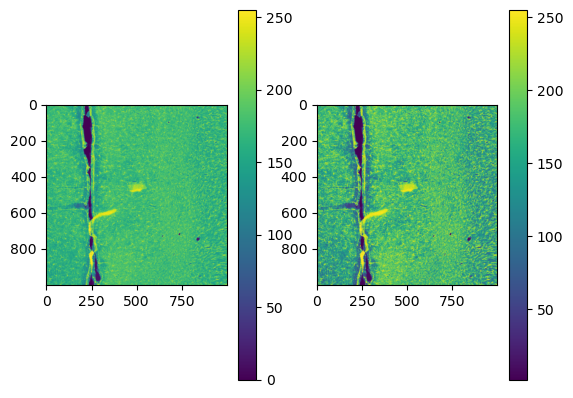

In [6]:
# show before and after image enhance side by side

plt.subplot(1, 2, 1)
plt.imshow(gray_image[15000:16000, 17500:18500])
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(gray_image_e[15000:16000, 17500:18500])
plt.colorbar()

In [10]:
#write both original and enhanced to test_micro_sam_r.tiff and test_micro_sam_e_r.tiff

from tifffile import TiffWriter

with TiffWriter(f'{in_dir}/test_micro_sam_r.tiff', bigtiff=True) as tif:
    tif.write(gray_image[15000:16000, 17500:18500])  # Adjusted indices

with TiffWriter(f'{in_dir}/test_micro_sam_e_r.tiff', bigtiff=True) as tif:
    tif.write(gray_image_e[15000:16000, 17500:18500])  # Adjusted indices

In [ ]:
import os
os.chdir(Path.home())  # YOLO resolves model path relative to cwd; must be local, not sshfs

model = YOLO("yolo11m-seg.pt")

region = (slice(15000, 16000), slice(17500, 18500))

color_img_o = cv2.cvtColor(gray_image[region].astype(np.uint8), cv2.COLOR_GRAY2BGR)
color_img_e = cv2.cvtColor(gray_image_e[region].astype(np.uint8), cv2.COLOR_GRAY2BGR)

results_o = model(color_img_o)
results_e = model(color_img_e)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, label, res in zip(axes, ["Original", "Enhanced"], [results_o, results_e]):
    n = len(res[0].boxes) if res[0].boxes is not None else 0
    ax.imshow(cv2.cvtColor(res[0].plot(), cv2.COLOR_BGR2RGB))
    ax.set_title(f'YOLO default — {label}  ({n} detections)')
plt.tight_layout()
plt.show()

In [ ]:
import os
import cv2
import numpy as np
from ultralytics import YOLO
os.chdir(Path.home())

model = YOLO("yolo11m-seg.pt")

region = (slice(15000, 16000), slice(17500, 18500))

def _to_color(img_2d):
    mn, mx = img_2d.min(), img_2d.max()
    norm = 255.0 * (img_2d - mn) / (mx - mn) if mx - mn > 0 else np.zeros_like(img_2d)
    return np.stack([norm.astype(np.uint8)] * 3, axis=-1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, label, slc in zip(axes,
                           ["Original", "Enhanced"],
                           [gray_image[region], gray_image_e[region]]):
    color_img = _to_color(slc)
    results = model.predict(source=color_img, conf=0.01, iou=0.3, imgsz=640, agnostic_nms=True)
    n_masks = len(results[0].masks.data) if results[0].masks is not None else 0
    ax.imshow(cv2.cvtColor(results[0].plot(), cv2.COLOR_BGR2RGB))
    ax.set_title(f'YOLO conf=0.01 — {label}  ({n_masks} masks)')
plt.tight_layout()
plt.show()

In [ ]:
import os
import cv2
import numpy as np
from ultralytics import YOLO
os.chdir(Path.home())

model = YOLO("yolo11m-seg.pt")

region = (slice(15000, 16000), slice(17500, 18500))

def _to_color(img_2d):
    mn, mx = img_2d.min(), img_2d.max()
    norm = 255.0 * (img_2d - mn) / (mx - mn) if mx - mn > 0 else np.zeros_like(img_2d)
    return np.stack([norm.astype(np.uint8)] * 3, axis=-1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, label, slc in zip(axes,
                           ["Original", "Enhanced"],
                           [gray_image[region], gray_image_e[region]]):
    color_img = _to_color(slc)
    results = model(color_img, imgsz=1024)
    n_masks = len(results[0].masks.data) if results[0].masks is not None else 0
    ax.imshow(cv2.cvtColor(results[0].plot(), cv2.COLOR_BGR2RGB))
    ax.set_title(f'YOLO imgsz=1024 — {label}  ({n_masks} masks)')
plt.tight_layout()
plt.show()

In [22]:
results[0].show()

In [14]:
results

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted p

In [29]:
from cellpose import models

model = models.CellposeModel(model_type="cyto3", gpu=False)


model_type argument is not used in v4.0.1+. Ignoring this argument...


In [ ]:
region = (slice(15000, 16000), slice(17500, 18500))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, label, slc in zip(axes,
                           ["Original", "Enhanced"],
                           [gray_image[region], gray_image_e[region]]):
    m = model.eval(slc, diameter=None, channels=[0, 0], flow_threshold=0.4, cellprob_threshold=0.95)
    n_cells = int((m[0] > 0).any(axis=(0,1)).sum()) if m[0].ndim > 2 else int(np.unique(m[0]).shape[0] - 1)
    ax.imshow(m[0])
    ax.set_title(f'Cellpose — {label}  ({np.unique(m[0]).shape[0] - 1} cells)')
plt.tight_layout()
plt.show()

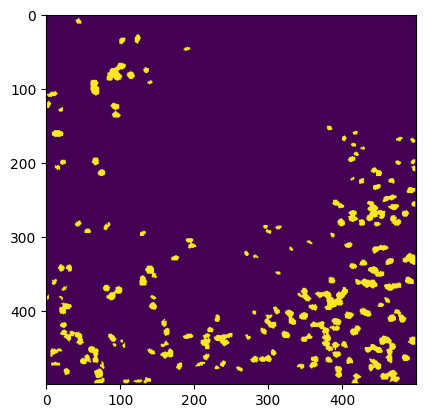

In [35]:
plt.imshow(m[0]>0)

In [37]:
from micro_sam.automatic_segmentation import get_predictor_and_segmenter, automatic_instance_segmentation


/Users/KARATB01/venv_all/lib/python3.13/site-packages/torch_em/util/image.py:6: UserWarning: elf has switched from the affogato, vigra, and nifty librares to https://github.com/computational-cell-analytics/bioimage-cpp as new backed for custom functionality implemented in C++, e.g. mutex watershed, multicut etc. This may lead to some changes in behavior and interface. If you run into issues with the new version consider installing a version < 0.9. Please also consider raising an issue on github so that we are aware of issues with the migration.
  from elf.io import open_file
/Users/KARATB01/venv_all/lib/python3.13/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.4.3)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


In [40]:
# Load the Segment Anything for Microscopy model.
predictor, segmenter = get_predictor_and_segmenter(model_type="vit_b_lm")

Using apple MPS device.


100%|████████████████████████████████████████| 375M/375M [00:00<00:00, 201GB/s]
100%|█████████████████████████████████████| 38.4M/38.4M [00:00<00:00, 18.2GB/s]


In [ ]:
region = (slice(15000, 15100), slice(17500, 17600))

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, label, slc in zip(axes,
                           ["Original", "Enhanced"],
                           [gray_image[region], gray_image_e[region]]):
    instances = automatic_instance_segmentation(
        predictor=predictor,
        segmenter=segmenter,
        input_path=slc,
    )
    ax.imshow(instances > 0)
    ax.set_title(f'micro_sam — {label}  ({np.unique(instances).shape[0] - 1} instances)')
plt.tight_layout()
plt.show()

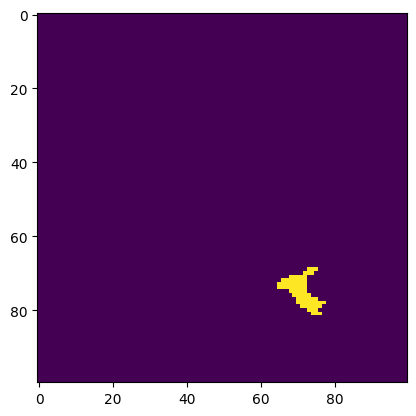

In [43]:
plt.imshow(instances>0)